# GPT-2 — autoLRP attribution

GPT-2 from HuggingFace, run as it is. `attn_implementation='eager'` is not needed: a fused attention kernel is either decomposed by autoLRP during the forward or handled as one node, with the same result.

We attribute the next-token prediction back to the input tokens.

In [1]:
import sys
sys.path.insert(0, '..')          # examples/showcase: _common
sys.path.insert(0, '../../..')    # repo root: autoLRP (or `pip install -e .`)
import torch
from transformers import GPT2Tokenizer, GPT2LMHeadModel

import autolrp
from autolrp import LRPConfig, BASE, CPLRP, explain, explain_summary
from _common import show_text_attribution

device = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_ID = 'gpt2'

/opt/miniconda3/envs/waleed/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tok = GPT2Tokenizer.from_pretrained(MODEL_ID)
model = GPT2LMHeadModel.from_pretrained(MODEL_ID).eval().to(device)

class GPT2FromEmb(torch.nn.Module):
    """Embeddings → next-token logits (mean-centered for LRP)."""
    def __init__(self, m):
        super().__init__()
        self.h = m.transformer.h
        self.ln_f = m.transformer.ln_f
        self.lm_head = m.lm_head
    def forward(self, inputs_embeds):
        x = inputs_embeds
        for block in self.h:
            out = block(x)
            x = out[0] if isinstance(out, tuple) else out
        logits = self.lm_head(self.ln_f(x))[:, -1, :]
        return logits - logits.mean(dim=-1, keepdim=True)

wrapper = GPT2FromEmb(model).eval().to(device)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 5824.71it/s]


In [3]:
text = 'A rose by any other name would smell as'
ids = tok(text, return_tensors='pt').input_ids.to(device)
positions = torch.arange(ids.shape[1], device=device)
emb = (model.transformer.wte(ids) + model.transformer.wpe(positions)).detach()

with torch.no_grad():
    pred = wrapper(emb).argmax(-1).item()
print(f'Top next token: {tok.decode([pred])!r}')

Top next token: ' sweet'


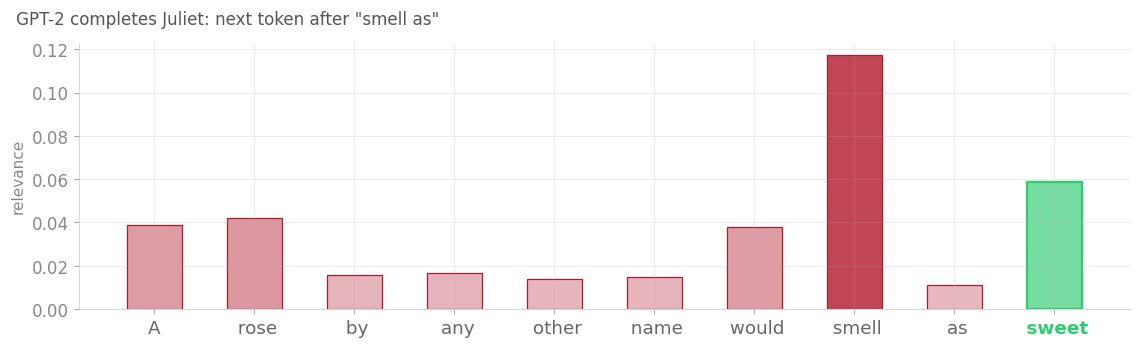

In [4]:
x = autolrp.tensor(emb)
out = wrapper(x)
out[0, pred].lrp(config=LRPConfig(rule={**BASE, **CPLRP}))   # epsilon on the linear layers, attention weights as constants

tokens = [t.replace('Ġ', ' ') for t in tok.convert_ids_to_tokens(ids[0])]
rel = x.relevance[0].sum(-1).detach().cpu().numpy()
show_text_attribution(tokens, rel, predicted_token=tok.decode([pred]), prompt_text='GPT-2 completes Juliet: next token after "smell as"')

## What ran

`explain` lists the config entry and the rule that each node received; shape ops, where the gradient is already the routing, are filtered out here.

In [5]:
rows = explain(wrapper(autolrp.tensor(emb))[0, pred], LRPConfig(rule={**BASE, **CPLRP}))
print(explain_summary([r for r in rows if r[2] != 'native gradient']))

count  node                      key                   what
   48  AddBackward               AddBackward           proportional
   48  AddmmBackward0            AddmmBackward         epsilon (lhs)
   48  MulBackward0              MulBackward           proportional (lhs)
   25  NativeLayerNormBackward0  NativeLayerNormBackward  layernorm_identity
   12  BmmBackward0              bilinear              epsilon (rhs)
   12  BmmBackward0              bilinear              epsilon (both)
   12  MulBackward0              MulBackward           proportional
   12  PowBackward               PowBackward           passthrough
   12  SoftmaxBackward           SoftmaxBackward       passthrough
   12  TanhBackward              TanhBackward          passthrough
    1  MeanBackward              MeanBackward          reduction_proportional
    1  MmBackward0               MmBackward            epsilon (lhs)
    1  SubBackward               statistic_operand     proportional (lhs)
